# Polynomial Regression

The goal is to predict the numerical disease progression target using multiple input features.

Polynomial Regression is used to capture non-linear relationships by creating polynomial and interaction features from the original features.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Load Dataset

In [33]:
df = pd.read_csv("../Dataset/diabetes.csv")

In [34]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [35]:
df.shape

(442, 11)

In [36]:
df.columns

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6',
       'target'],
      dtype='str')

In [37]:
df.isnull().sum()

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

In [38]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-7.284269e-18,2.348549e-17,-2.087320e-16,-4.571507e-17,-9.293722e-18,4.420798e-17,2.135044e-18,2.913707e-17,9.143013e-17,1.431736e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


## Separate Features and Target

The `target` column is the value we want to predict.

The remaining 10 columns are used as input features.

In [39]:
X = df.drop("target", axis=1)
y = df["target"]

print("Features:")
print(X.columns.tolist())
print("\nTarget:")
print(y.name)

Features:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Target:
target


In [40]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (442, 10)
y shape: (442,)


## Train-Test Split

The dataset is divided into training and testing data.

80% of the data is used for training and 20% is used for testing.

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (353, 10)
Testing data: (89, 10)


## Create Polynomial Features

Polynomial Regression creates additional features such as squared terms and interaction terms.

For example:

`bmi` → `bmi²`

`age` and `bmi` → `age × bmi`

This allows the model to capture non-linear relationships.

In [42]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
print("Original number of features:", X_train.shape[1])
print("Polynomial number of features:", X_train_poly.shape[1])

Original number of features: 10
Polynomial number of features: 65


### Feature names

In [43]:
poly_features = poly.get_feature_names_out(X.columns)
print(poly_features)

['age' 'sex' 'bmi' 'bp' 's1' 's2' 's3' 's4' 's5' 's6' 'age^2' 'age sex'
 'age bmi' 'age bp' 'age s1' 'age s2' 'age s3' 'age s4' 'age s5' 'age s6'
 'sex^2' 'sex bmi' 'sex bp' 'sex s1' 'sex s2' 'sex s3' 'sex s4' 'sex s5'
 'sex s6' 'bmi^2' 'bmi bp' 'bmi s1' 'bmi s2' 'bmi s3' 'bmi s4' 'bmi s5'
 'bmi s6' 'bp^2' 'bp s1' 'bp s2' 'bp s3' 'bp s4' 'bp s5' 'bp s6' 's1^2'
 's1 s2' 's1 s3' 's1 s4' 's1 s5' 's1 s6' 's2^2' 's2 s3' 's2 s4' 's2 s5'
 's2 s6' 's3^2' 's3 s4' 's3 s5' 's3 s6' 's4^2' 's4 s5' 's4 s6' 's5^2'
 's5 s6' 's6^2']


## Train Polynomial Regression Model

Polynomial Regression can be implemented by first creating polynomial features and then applying a linear regression model.

Here we use Ridge Regression so that regularization can help control overfitting.

In [44]:
model = Ridge(alpha=1.0)
model.fit(X_train_poly, y_train)
print("Polynomial Ridge Regression model trained.")

Polynomial Ridge Regression model trained.


In [45]:
y_pred = model.predict(X_test_poly)
print(y_pred[:10])

[157.12619283 162.92989425 155.0912971  247.60233236 143.77554723
 126.30013111 218.54309472 190.16274392 113.8968829  134.4845944 ]


In [46]:
comparison = pd.DataFrame({"Actual": y_test.values, "Predicted": y_pred})
comparison.head(10)

,Actual,Predicted
0,219.0,157.126193
1,70.0,162.929894
2,202.0,155.091297
3,230.0,247.602332
4,111.0,143.775547
5,84.0,126.300131
6,242.0,218.543095
7,272.0,190.162744
8,94.0,113.896883
9,96.0,134.484594


## Model Evaluation

The model is evaluated using:

- MAE
- MSE
- RMSE
- R² score

In [18]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 46.1241
MSE  : 3075.1322
RMSE : 55.4539
R²   : 0.4196


## Overfitting

## Compare Polynomial Degrees

Higher polynomial degrees create more features and make the model more flexible.

However, a very high degree can cause overfitting.

We compare degree 1, degree 2 and degree 3.

In [20]:
results = []
for degree in [1, 2, 3]:
    model = Pipeline([("poly", PolynomialFeatures(degree=degree, include_bias=False)), ("ridge", Ridge(alpha=1.0))])
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    results.append({
        "Degree": degree,
        "Train R²": train_r2,
        "Test R²": test_r2
    })
results_df = pd.DataFrame(results)
results_df

,Degree,Train R²,Test R²
0,1,0.442403,0.419153
1,2,0.442971,0.419584
2,3,0.442984,0.419589


## Regularization

Polynomial features can make the model more complex and increase the risk of overfitting.

Ridge Regression adds L2 regularization to the model.

The `alpha` parameter controls the strength of regularization.

A larger `alpha` means stronger regularization.

In [49]:
results = []
for alpha in [0.01, 0.1, 1, 10, 100]:
    model = Pipeline([("poly", PolynomialFeatures(degree=2, include_bias=False)), ("ridge", Ridge(alpha=alpha))])
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    results.append({
        "Alpha": alpha,
        "Train R²": train_r2,
        "Test R²": test_r2
    })
alpha_results = pd.DataFrame(results)
alpha_results

,Alpha,Train R²,Test R²
0,0.01,0.543695,0.484222
1,0.10,0.523844,0.465925
2,1.00,0.442971,0.419584
3,10.00,0.163491,0.161253
4,100.00,0.022342,0.012176


## Final Polynomial Regression Model

Based on the comparison above, we use degree 2 polynomial features with Ridge Regression.

Degree 2 provides additional non-linear features while keeping the model complexity under control.

In [50]:
final_model = Pipeline([("poly", PolynomialFeatures(degree=2, include_bias=False)), ("ridge", Ridge(alpha=1.0))])
final_model.fit(X_train, y_train)
final_pred = final_model.predict(X_test)

In [51]:
mae = mean_absolute_error(y_test, final_pred)
mse = mean_squared_error(y_test, final_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, final_pred)

print("Final Polynomial Regression Results")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

Final Polynomial Regression Results
MAE  : 46.1241
MSE  : 3075.1322
RMSE : 55.4539
R²   : 0.4196


### Actual vs Predicted Values

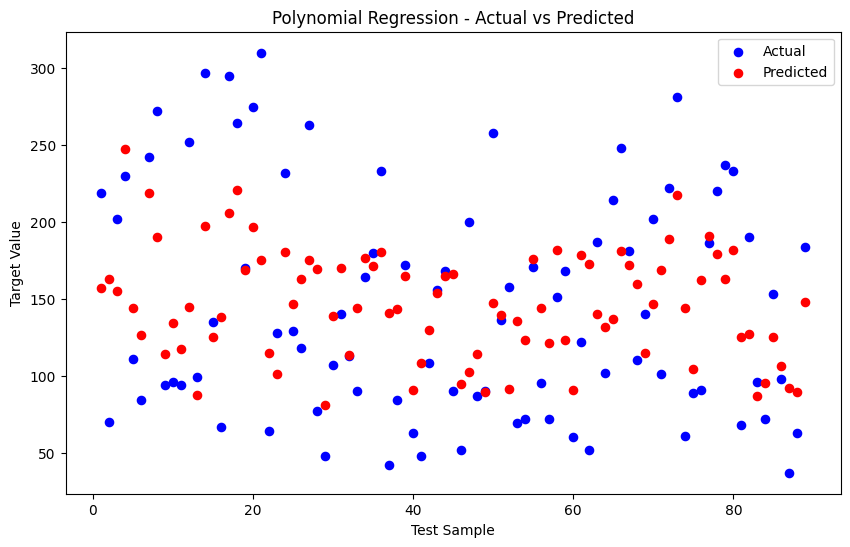

In [52]:
plt.figure(figsize=(10, 6))
sample_numbers = range(1, len(y_test) + 1)
plt.scatter(sample_numbers, y_test, label="Actual", color="blue", s=35)
plt.scatter(sample_numbers, final_pred, label="Predicted", color="red", s=35)
plt.xlabel("Test Sample")
plt.ylabel("Target Value")
plt.title("Polynomial Regression - Actual vs Predicted")
plt.legend()
plt.show()

## Conclusion

Polynomial Regression extends Linear Regression by creating polynomial and interaction features.

For the Diabetes dataset, degree 2 polynomial features were used to capture possible non-linear relationships between the input features and the target.

Since polynomial features increase model complexity, Ridge Regression was used for regularization.

The model was evaluated using MAE, MSE, RMSE and R² score.

Comparing training and testing performance helps identify overfitting. Regularization helps control the size of model coefficients and reduces the risk of overfitting.

In [28]:
Pipeline([("poly", PolynomialFeatures(degree=2, include_bias=False)), ("ridge", Ridge(alpha=1.0))])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('poly', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bo